In [18]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import run_fair

import utils_MLP

from bayes_opt import BayesianOptimization
from scipy import signal

import seaborn as sns
from cmcrameri import cm

import warnings

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
start, stop = 1750, 2500
years = np.arange(start, stop)
n_steps = len(years)

FS = 1
agents = ['CO2','CH4','N2O','Sulfur','BC']
emis_dict_valid = run_fair.load_cmip7_extensions(n_steps, agents)

zero_emis = np.zeros(n_steps)

# Combined steps
step_dict = {}
for i, a in enumerate(agents):
  year_step = i * 50
  step = np.zeros(n_steps)
  step[year_step:] = 10
  step_dict[a] = step
emis_dict_valid['step'] = run_fair.ensure_all_agents(step_dict, n_steps)

# Combined pulses
pulse_dict = {}
for i, a in enumerate(agents):
  year_pulse = i * 50
  pulse = np.zeros(n_steps)
  pulse[year_pulse] = 1000
  pulse_dict[a] = pulse
emis_dict_valid['pulse'] = run_fair.ensure_all_agents(pulse_dict, n_steps)

delT_dict_valid = {}

CMIP7_priority_2_ext = ['HO','VLO','L','ME','MO']
idealized_valid = ['step','pulse']

scenarios_valid = CMIP7_priority_2_ext.copy() + idealized_valid.copy()

for scen in scenarios_valid:
  # Use a fresh FaIR instance for each scenario to prevent state carryover
  f = run_fair.build_fair(start, stop)
  emis = {a: np.zeros(n_steps) for a in agents}
  for agent in agents:
    emis[agent] = emis_dict_valid[scen][agent]

  run_fair.set_emissions(f, years, emis)
  _, _, T_mean, _ = run_fair.run_fair(f, years)
  delT_dict_valid[scen] = T_mean

# Format validation data
valid_series = []
for scen in scenarios_valid:
  valid_series.append(
    (emis_dict_valid[scen], delT_dict_valid[scen])
  )

In [40]:
def zero_mean(t, offset):
    """A mean trend with an offset."""
    return np.zeros_like(t) + offset

def sinusoidal_cycle(t, amplitude, frequency):
    """A long-period sinusoidal cycle."""
    return amplitude * np.sin(2 * np.pi * frequency * t)

def sine_sweep(t, amplitude, f0, f1):
    """A sinusoidal sweep across multiple frequencies"""
    return amplitude * signal.chirp(t, f0, n_steps, f1)

def multi_trend(t, A_slow, f_slow,
                       A_fast, f_fast,
                       A_step, k, t_center):
    """
    A unified signal combining a slow sine, a fast sine, and a smooth step (tanh).
    This creates a complex, continuous signal for optimization.
    """
    slow_sine_component = A_slow * np.sin(2 * np.pi * f_slow * t)
    fast_sine_component = A_fast * np.sin(2 * np.pi * f_fast * t)
    step_component = A_step * np.tanh(k * (t - t_center))

    return slow_sine_component + fast_sine_component + step_component

def ornstein_uhlenbeck(t, theta, sigma, mu):
    """
    Generates an Ornstein-Uhlenbeck process.
    This process models mean-reverting behavior, where the process is
    continuously pulled towards a long-term mean.

    Args:
        t (np.ndarray): Time array.
        theta (float): Drift term, rate of reversion to the mean.
        sigma (float): Standard deviation of the noise (volatility).
        mu (float): The long-term mean of the process.

    Returns:
        np.ndarray: The generated Ornstein-Uhlenbeck process.
    """
    n_steps = len(t)
    # Assume constant time steps
    dt = t[1] - t[0] if n_steps > 1 else 1
    x = np.zeros(n_steps)
    # Start the process at its long-term mean
    x[0] = mu

    # Iterate through time to generate the process
    for i in range(1, n_steps):
        drift = theta * (mu - x[i-1]) * dt
        noise = sigma * np.sqrt(dt) * np.random.randn()
        x[i] = x[i-1] + drift + noise
    return x

eps = 1e-7
MEAN_FUNCTIONS = {
    "const": {"function": zero_mean,
             "params": {"m_param_offset": (0.0, 20.0)}},
    "sinusoid": {
        "function": sinusoidal_cycle,
        "params": {"m_param_amplitude": (10.0, 75.0),
                   "m_param_frequency": (0.0005, 0.005)}, # 2,000 to 200 years
    },
    "sweep":{
        "function": sine_sweep,
        "params": {"m_param_amplitude": (10.0, 75.0),
                   "m_param_f0": (0.0005, 0.005 - eps), # 2,000 to 200 years
                   "m_param_f1": (0.005 + eps, 0.25)}   # 200 to 4 years
    },
    "multi":{
        "function": multi_trend,
        "params": {
            # Slow Sinusoid
            "m_param_A_slow": (0.0, 200.0),
            "m_param_f_slow": (0.0025, 0.01), # Periods of 400-2000 years

            # Fast Sinusoid
            "m_param_A_fast": (0.0, 100.0),
            "m_param_f_fast": (0.02, 0.5),      # Periods of 10-50 years

            # Smooth Step
            "m_param_A_step": (0.0, 100.0),
            "m_param_k": (0.02, 0.4),          # Transition steepness (10-100 years)
            "m_param_t_center": (0.05 * n_steps, 0.9 * n_steps)},
    },
    "ornstein_uhlenbeck": {
        "function": ornstein_uhlenbeck,
        "params": {
            "m_param_theta": (0.001, 1.0),   # Drift term (reversion speed)
            "m_param_sigma": (1.0, 100.0),   # Std. dev. of the noise
            "m_param_mu": (0.0, 100.0)       # Long-term mean
        }
    }
}

AGENTS = agents.copy()
MEAN_FUNC_NAME = 'sinusoid'
CONFIG = {
    "CHOSEN_MEAN_FUNCTION": MEAN_FUNC_NAME,
    "N_INNER_SAMPLES": 5,  # Stochastic samples per evaluation
    "NOISE_PARAM_SPACE": {
        "sigma": (50.0, 200.0),
        "f_low": (0.01, 0.1 - eps),
        "f_high": (0.1 + eps, 0.5 - eps),
    },
}
warnings.simplefilter('ignore')

def evaluate_parameter_set(params, mean_func, agents):
    """
    Evaluates a parameter set for N agents, each with unique parameters.
    """
    nrmse_scores = []
    for _ in range(CONFIG["N_INNER_SAMPLES"]):
        # A. Generate a base set of uncorrelated noise signals
        uncorrelated_noise = utils_MLP.generate_uncorrelated_signals(n=len(agents), signal_length=n_steps)
        emissions_dict = {}

        # B. Loop through each agent to build its unique signal
        for i, agent in enumerate(agents):

            # Dynamically get mean function parameters for this agent
            mean_func_params = {
                k.replace('m_param_', ''): v
                for k, v in params.items()
                if k.startswith(f'm_param_') and k.endswith(f'_{agent}')
            }
            # Clean the keys for the function call (e.g., 'm_param_amplitude_CO2' -> 'amplitude')
            mean_func_params_clean = {k.replace(f'_{agent}', ''): v for k, v in mean_func_params.items()}

            # C. Build the signal for this agent
            m_t = mean_func(np.arange(n_steps), **mean_func_params_clean)

            if CONFIG['CHOSEN_MEAN_FUNCTION'] == 'ornstein_uhlenbeck':
                # OU process has its own noise
                u_t = m_t
            else:
                # Extract this agent's specific parameters from the main params dict
                sigma = params[f'sigma_{agent}']
                f_low = params[f'f_low_{agent}']
                f_high = params[f'f_high_{agent}']

                base_noise = uncorrelated_noise[i]
                nyquist = 0.5 * FS
                b, a = signal.butter(4, [f_low/nyquist, f_high/nyquist], btype='band')
                w_t = signal.filtfilt(b, a, base_noise)
                w_t = (w_t - np.mean(w_t)) / np.std(w_t)

                u_t = m_t + sigma * w_t

            emissions_dict[agent] = u_t

        # D. Run the FaIR + MLP evaluation pipeline with the multi-agent emissions dict
        f_train = run_fair.build_fair(start, stop)
        run_fair.set_emissions(f_train, years, run_fair.ensure_all_agents(emissions_dict, n_steps))
        f_train.run(progress=False)

        if np.any(f_train.concentration.sel(specie='CO2') < 100) or  np.any(f_train.concentration.sel(specie='CH4') < 100):
            # This is an invalid run. We don't need to proceed.
            # We will use the average of any scores we have so far, but add a huge penalty.
            # If it's the first run, this will just be the penalty.
            penalty = 1e9
            current_mean = np.mean(nrmse_scores) if nrmse_scores else 0
            return current_mean + penalty # Return a terrible score

        _, _, training_temp, _ = run_fair.run_fair(f_train, years)

        train_scenarios = ["bo_training_run"]
        # The data structure for train_series is now (emissions_dict, temp_series)
        train_series = [(emissions_dict, training_temp)]

        error_dict, _ = utils_MLP.evaluate_trainsets_vs_tests(
            train_scenarios, train_series, scenarios_valid, valid_series, agents=agents
        )
        scores_for_this_run = [err for err in error_dict["bo_training_run"].values()]
        nrmse_scores.append(np.mean(scores_for_this_run))

    return np.mean(nrmse_scores)


# --- Bayesian Optimization Integration ---
# 1. Pre-select the mean function and build the parameter bounds
chosen_config = MEAN_FUNCTIONS[CONFIG["CHOSEN_MEAN_FUNCTION"]]
mean_function_to_run = chosen_config["function"]

pbounds = {}
for agent in AGENTS:
    # Add noise parameters for this agent
    if CONFIG['CHOSEN_MEAN_FUNCTION'] != 'ornstein_uhlenbeck':
        for param, bounds in CONFIG["NOISE_PARAM_SPACE"].items():
            pbounds[f'{param}_{agent}'] = bounds
    # Add mean function parameters for this agent
    for param, bounds in chosen_config["params"].items():
        pbounds[f'{param}_{agent}'] = bounds

print("Starting Bayesian Optimization...")
print(f"Agents: {AGENTS}")
print(f"Mean Function: '{CONFIG['CHOSEN_MEAN_FUNCTION']}'")
print(f"Optimizing over {len(pbounds)} parameters.\n")

# B. Define the black-box function for the optimizer
def black_box_for_bo(**params):
    # Enforce f_low < f_high for each agent
    for agent in AGENTS:
        if CONFIG['CHOSEN_MEAN_FUNCTION'] != 'ornstein_uhlenbeck' and params[f'f_low_{agent}'] > params[f'f_high_{agent}']:
            return -np.inf # Return a very bad score if constraints are violated

    mean_nrmse = evaluate_parameter_set(params, mean_function_to_run, AGENTS)
    return -mean_nrmse

# C. Instantiate and run the optimizer
# 3. Instantiate and run the optimizer
optimizer = BayesianOptimization(
    f=black_box_for_bo,
    pbounds=pbounds,
    random_state=42, # for reproducibility
    verbose=1
)

n_iter = 50
for i in range(n_iter):
    next_point = optimizer.suggest()
    target = black_box_for_bo(**next_point)
    optimizer.register(params=next_point, target=target)

    if i % 5 == 0:
        optimizer.save_state(f'data/Optimization/opt_FaIR_all_ghgs_m={MEAN_FUNC_NAME}.json')

print("\nOptimization Complete!")
print(optimizer.max)

Starting Bayesian Optimization...
Agents: ['CO2', 'CH4', 'N2O', 'Sulfur', 'BC']
Mean Function: 'sinusoid'
Optimizing over 25 parameters.

| 2         | -0.993712 | 141.13172 | 0.0104805 | 0.4141779 | 51.056612 | 0.0025282 | 147.33009 | 0.0238273 | 0.4037197 | 48.758314 | 0.0006424 | 151.47148 | 0.0137879 | 0.3624025 | 24.761017 | 0.0034663 | 181.96240 | 0.0958838 | 0.2475137 | 52.736733 | 0.0024528 | 119.74061 | 0.0262789 | 0.4187192 | 13.570666 | 0.0031221 |
| 6         | -0.402884 | 96.960537 | 0.0673143 | 0.3395209 | 55.219185 | 0.0049650 | 147.65086 | 0.0609448 | 0.1527033 | 22.396277 | 0.0006589 | 95.783966 | 0.0784519 | 0.1207901 | 57.507889 | 0.0013212 | 115.96739 | 0.0306022 | 0.2608791 | 66.207515 | 0.0011173 | 155.04118 | 0.0888436 | 0.1295353 | 14.214513 | 0.0048668 |
| 13        | -0.243074 | 142.83426 | 0.0334267 | 0.4405634 | 25.387907 | 0.0024338 | 65.743088 | 0.0447730 | 0.2179029 | 35.090185 | 0.0010172 | 166.42169 | 0.0870717 | 0.4084381 | 72.992288 | 0.0038114 | 94.3

In [46]:
def plot_optimized_signals(best_params, mean_func, agents):
    """
    Generates and plots one instance of the optimized training signals.
    """
    base_noise = utils_MLP.generate_uncorrelated_signals(len(agents), n_steps)
    emissions_dict = {}

    # Reconstruct the signals using the best parameters
    for i, agent in enumerate(agents):
        mean_func_params = {
                k.replace('m_param_', ''): v
                for k, v in best_params.items()
                if k.startswith(f'm_param_') and k.endswith(f'_{agent}')
            }
        mean_func_params_clean = {k.replace(f'_{agent}', ''): v for k, v in mean_func_params.items()}
        m_t = mean_func(np.arange(n_steps), **mean_func_params_clean)

        if CONFIG['CHOSEN_MEAN_FUNCTION'] == 'ornstein_uhlenbeck':
                # OU process has its own noise
                u_t = m_t
        else:
            # Extract this agent's specific parameters from the main params dict
            sigma = best_params[f'sigma_{agent}']
            f_low = best_params[f'f_low_{agent}']
            f_high = best_params[f'f_high_{agent}']

            w_t_filtered = signal.filtfilt(signal.butter(4, [f_low/(0.5*FS), f_high/(0.5*FS)], btype='band')[0],
                                     signal.butter(4, [f_low/(0.5*FS), f_high/(0.5*FS)], btype='band')[1],
                                     base_noise[i])
            w_t_filtered = (w_t_filtered - np.mean(w_t_filtered)) / np.std(w_t_filtered)
            u_t = m_t + sigma * w_t_filtered

        emissions_dict[agent] = u_t

    # Create the stacked plot
    fig, axes = plt.subplots(len(agents), 1, figsize=(12, 4 * len(agents)), sharex=True)
    fig.suptitle('Optimized Training Signals', fontsize=16, weight='bold')

    for i, agent in enumerate(agents):
        ax = axes[i] if len(agents) > 1 else axes
        ax.plot(years, emissions_dict[agent], color='dodgerblue')
        ax.set_title(f'Forcing Signal for {agent}')
        ax.set_ylabel('Emissions (GtC/yr)')
        ax.grid(True, alpha=0.4)

    axes[-1].set_xlabel('Year')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

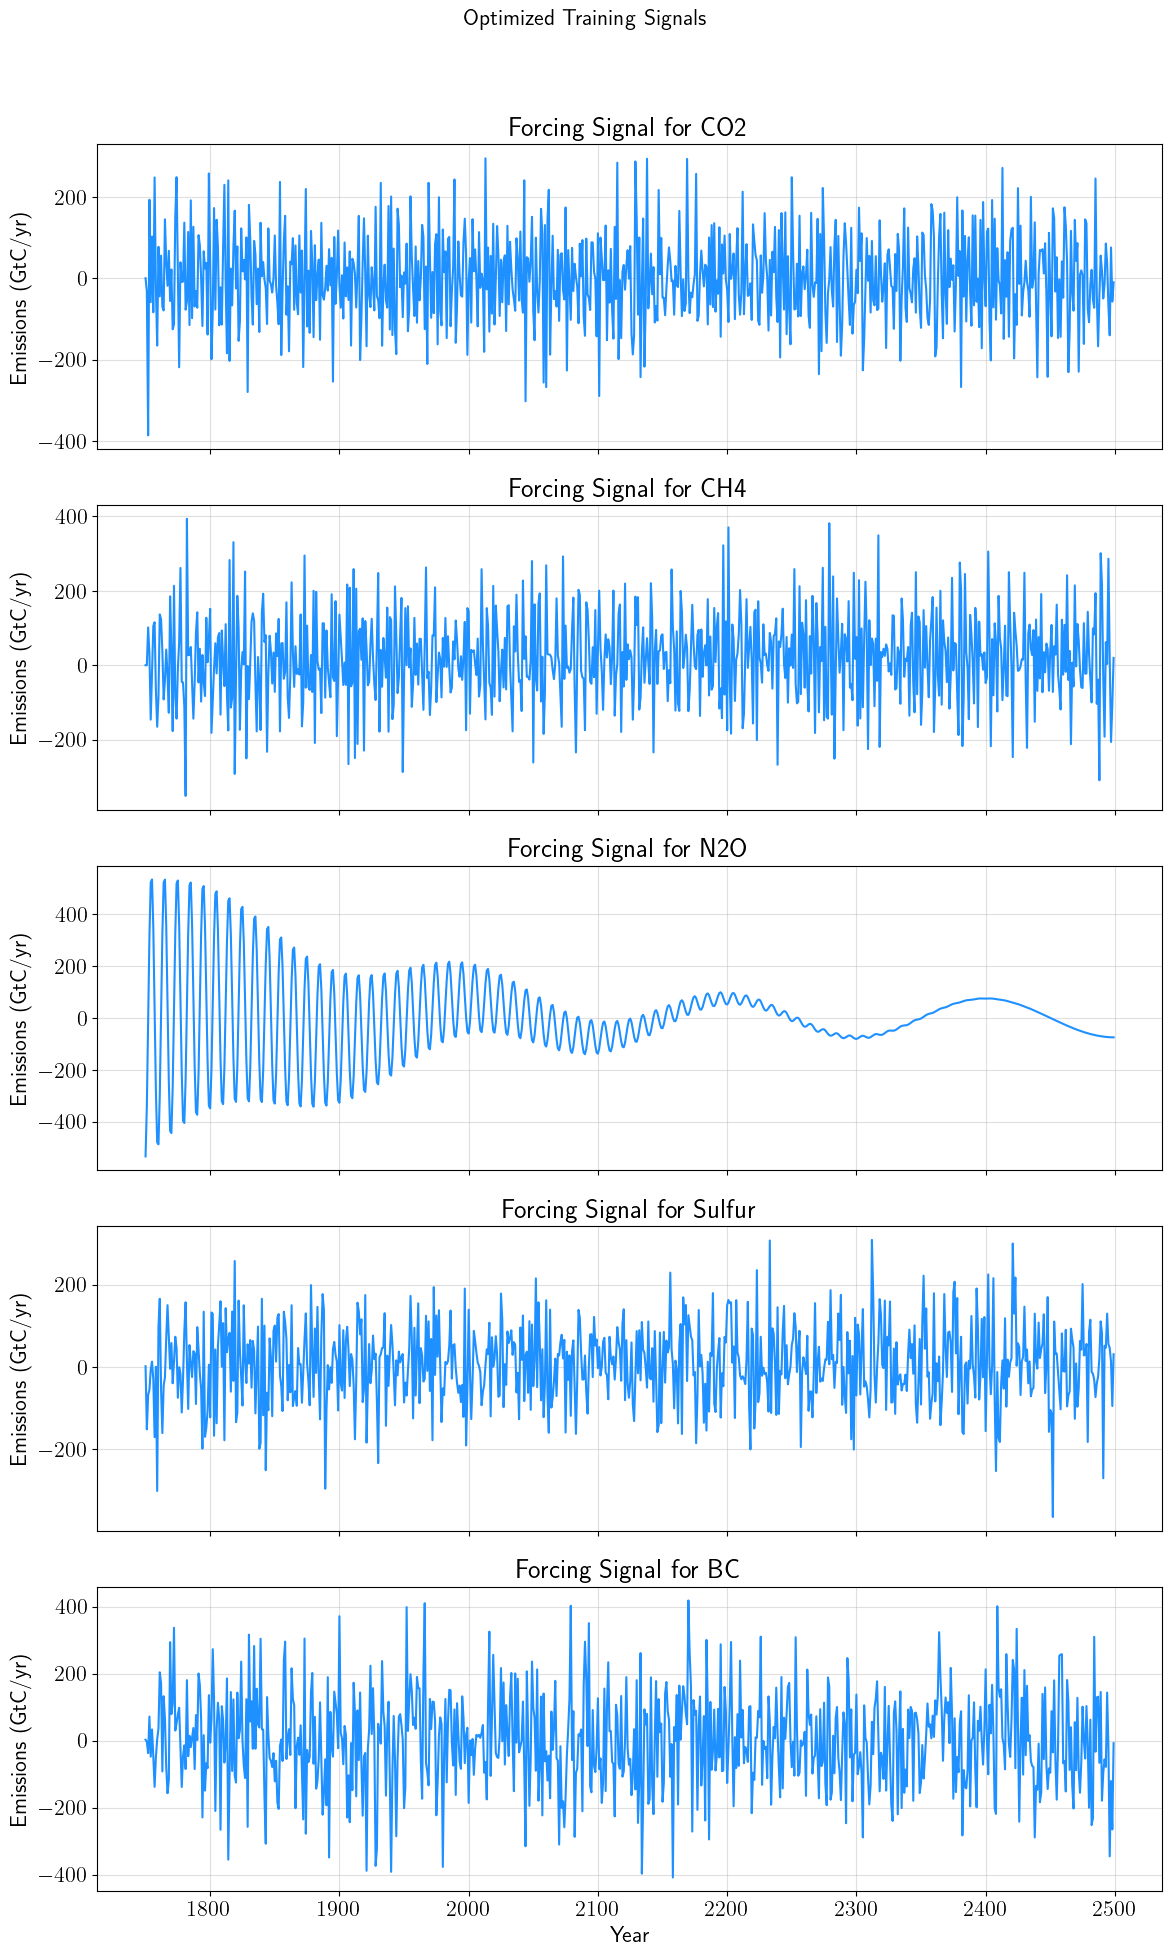

In [47]:
best_params = optimizer.max['params']
plot_optimized_signals(best_params, mean_function_to_run, AGENTS)

In [49]:
def get_detailed_nrmse_breakdown(best_params, mean_func, agents):
    """
    Runs the evaluation one time with the best parameters to get the
    NRMSE breakdown for each individual test scenario.
    """
    # 1. Reconstruct the multi-agent emissions dictionary from the best parameters
    uncorrelated_noise = utils_MLP.generate_uncorrelated_signals(n=len(agents), signal_length=n_steps)
    emissions_dict = {}
    for i, agent in enumerate(agents):
        mean_func_params = {
                k.replace('m_param_', ''): v
                for k, v in best_params.items()
                if k.startswith(f'm_param_') and k.endswith(f'_{agent}')
            }
        mean_func_params_clean = {k.replace(f'_{agent}', ''): v for k, v in mean_func_params.items()}

        m_t = mean_func(np.arange(n_steps), **mean_func_params_clean)

        if CONFIG['CHOSEN_MEAN_FUNCTION'] == 'ornstein_uhlenbeck':
            # OU process has its own noise
            u_t = m_t
        else:
            # Extract this agent's specific parameters from the main params dict
            sigma = best_params[f'sigma_{agent}']
            f_low = best_params[f'f_low_{agent}']
            f_high = best_params[f'f_high_{agent}']

            base_noise = uncorrelated_noise[i]
            nyquist = 0.5 * FS
            b, a = signal.butter(4, [f_low/nyquist, f_high/nyquist], btype='band')
            w_t = signal.filtfilt(b, a, base_noise)
            w_t = (w_t - np.mean(w_t)) / np.std(w_t)

            u_t = m_t + sigma * w_t

        emissions_dict[agent] = u_t

    # 2. Run the full FaIR and MLP evaluation pipeline just once
    f_train = run_fair.build_fair(start, stop)
    run_fair.set_emissions(f_train, years, run_fair.ensure_all_agents(emissions_dict, n_steps))
    f_train.run(progress=False)
    _, _, training_temp, _ = run_fair.run_fair(f_train, years)

    train_scenarios = ["best_run"]
    train_series = [(emissions_dict, training_temp)]

    error_dict, yhat_dict = utils_MLP.evaluate_trainsets_vs_tests(
        train_scenarios, train_series, scenarios_valid, valid_series, agents=agents
    )

    return error_dict, yhat_dict

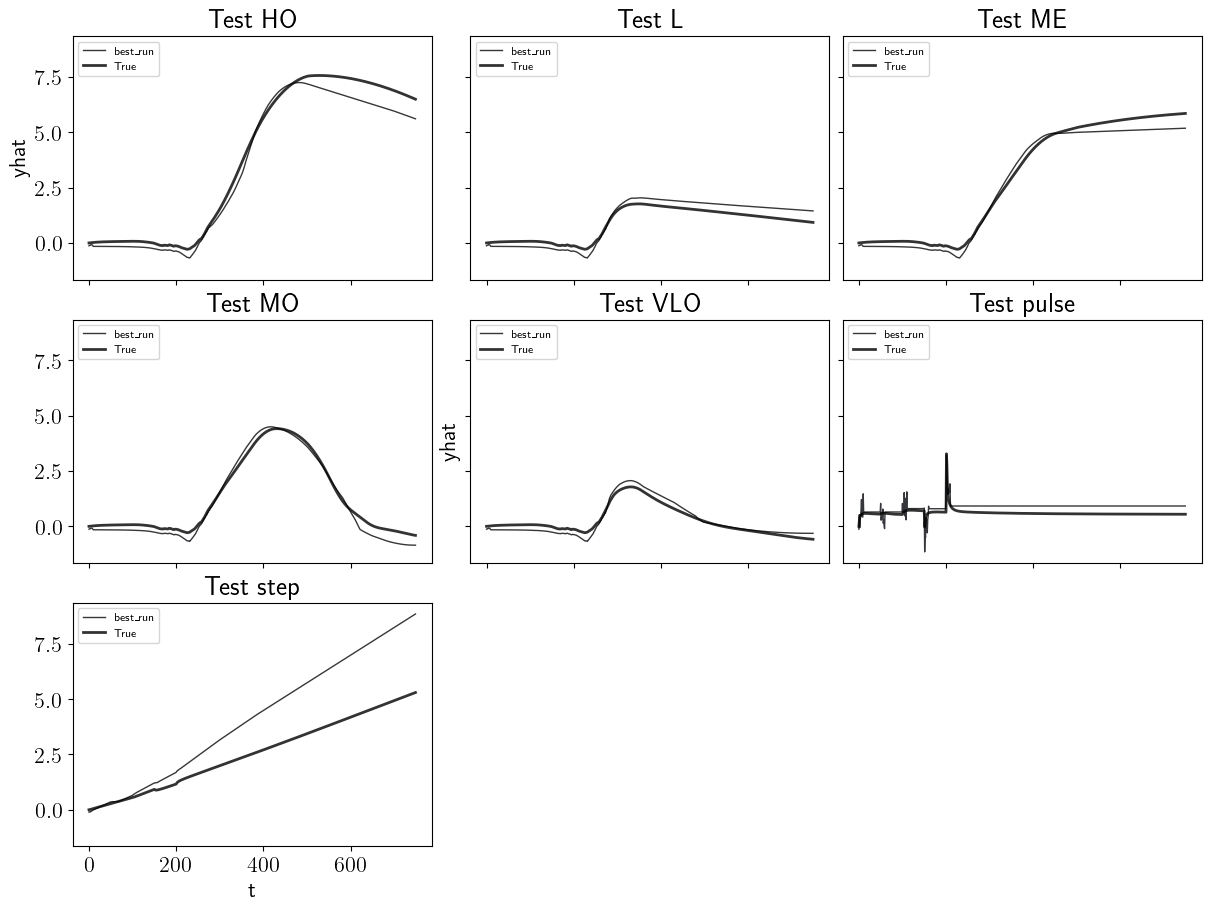

In [50]:
error_dict, yhat_dict = get_detailed_nrmse_breakdown(best_params, mean_function_to_run, AGENTS)
utils_MLP.plot_yhats_grid(error_dict, yhat_dict, delT_dict_valid)

In [51]:
print(error_dict['best_run'].values())
print(sum(error_dict['best_run'].values()) / len(error_dict['best_run']))

dict_values([0.06856260574136698, 0.11405641467206651, 0.18148812040749573, 0.05925290826370681, 0.06373789309385589, 0.37070758434969375, 0.09660309897789254])
0.13634408935801118
